In [3]:
type("hello world")

str

In [1]:
import pandas as pd

print(pd. __version__)

2.0.3


In [2]:
import numpy as np
print(np. __version__)

1.24.3


               scorer  count
0        Lionel Messi     18
1          Harry Kane     18
2          Cyle Larin     16
3       Memphis Depay     15
4  Robert Lewandowski     14
5       Kylian Mbappé     13
6   Cristiano Ronaldo     12
7              Neymar     12
8   Vincent Aboubakar     12
9    Lautaro Martínez     11


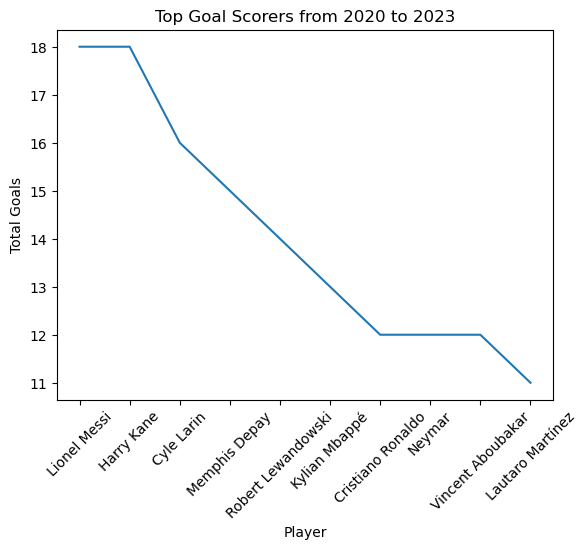

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

#importhing data from CSV
data = pd.read_csv('C:/Users/Asus/Downloads/archive/goalscorers.csv')

#filtering between 2020 and 2023
filtered_data = data[(data['date'] >= '2020-10-08') & (data['date'] <= '2023-07-16')]

#counting the number of repetitive names in order to calculate the goals scored
name_counts = filtered_data['scorer'].value_counts()
#taking the first 10 rows
top_names=name_counts.head(10)

#making them to a table with scorer and count as 2 columns
top_names_df = top_names.reset_index()
top_names_df.columns = ['scorer', 'count']

#plotting graph with top_names_df 
plt.plot(top_names_df['scorer'], top_names_df['count'])
plt.xlabel('Player')
plt.ylabel('Total Goals')
plt.title('Top Goal Scorers from 2020 to 2023')
plt.xticks(rotation=45)

print(top_names_df)

In [1]:
#Diamonds are forever

     Unnamed: 0  carat      cut color clarity  depth  table  price     x  \
0             1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95   
1             2   0.21  Premium     E     SI1   59.8   61.0    326  3.89   
2             3   0.23     Good     E     VS1   56.9   65.0    327  4.05   
3             4   0.29  Premium     I     VS2   62.4   58.0    334  4.20   
4             5   0.31     Good     J     SI2   63.3   58.0    335  4.34   
..          ...    ...      ...   ...     ...    ...    ...    ...   ...   
995         996   0.54    Ideal     D    VVS2   61.4   52.0   2897  5.30   
996         997   0.72    Ideal     E     SI1   62.5   55.0   2897  5.69   
997         998   0.72     Good     F     VS1   59.4   61.0   2897  5.82   
998         999   0.74  Premium     D     VS2   61.8   58.0   2897  5.81   
999        1000   1.12  Premium     J     SI2   60.6   59.0   2898  6.68   

        y     z  
0    3.98  2.43  
1    3.84  2.31  
2    4.07  2.31  
3    4.23  2.63

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2'),
  Text(1.4000000000000001, 0, '1.4')])

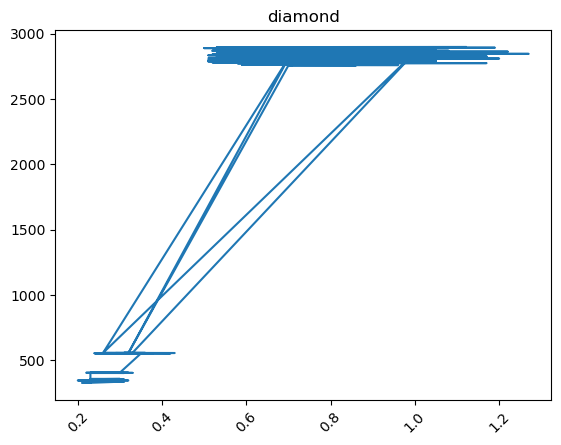

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Define the path to your CSV file
#file_path = 'C:/Users/Asus/Downloads/archive/diamonds.csv'

# Specify the columns you want to keep
columns_to_keep = ['carat', 'depth', 'price']

# Read the CSV file with only the selected columns
#df = pd.read_csv(file_path, usecols=columns_to_keep)



file=pd.read_csv('C:/Users/Asus/Downloads/archive/diamonds.csv',usecols=columns_to_keep)


file=pd.read_csv('C:/Users/Asus/Downloads/archive/diamonds.csv')

filtered_data=file.head(1000)                                      
print(filtered_data)

plt.plot(filtered_data['carat'], filtered_data['price'])
plt.title('diamond')
plt.xticks(rotation=45)








In [4]:
import pandas as pd
from bs4 import BeautifulSoup
import requests

file=pd.read_csv("C:/Users/Asus/Downloads/url.csv")
header = {
    "User-Agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Mobile Safari/537.36"
}


def get_response(url):
    response = requests.get(url)
    print(response)
    return response.text

    
def extract_price(url):
    page = requests.get(url, headers=header)
    soup = BeautifulSoup(page.text, 'html.parser')
    
    # Try finding the price using the first class
    price = soup.find("span", class_='a-price-whole')
    
    if price is None:
        # If the first attempt fails, try the second class
        page = requests.get(url)
        soup = BeautifulSoup(page.text, 'lxml')
        price = soup.find("div", class_='_16Jk6d')
        print("Price on https://dl.flipkart.com/s/OfbQRZNNNN is", price.text)
    else:
         print("Price on", url,"is",price.text)
         

    
def main():
    for index, row in file.iterrows():
        url = row['url']
        #get_response(url)
        extract_price(url)

if __name__ == "__main__":
    main()

Price on https://amzn.eu/d/39PCW0c is 2,299
Price on https://dl.flipkart.com/s/OfbQRZNNNN is ₹2,299


In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import smtplib

file=pd.read_csv("C:/Users/Asus/Downloads/url.csv")
header = {
    "User-Agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Mobile Safari/537.36"
}


def get_response(url):
    response = requests.get(url)
    print(response)
    return response.text

    
def extract_price(url):
   
    page = requests.get(url, headers=header)
    soup = BeautifulSoup(page.text, 'lxml')
    
    # Try finding the price using the first class
    price = soup.find("span", class_='a-price-whole')
    
    if price is None:
        # If the first attempt fails, try the second class
        page = requests.get(url)
        soup = BeautifulSoup(page.text, 'lxml')
        price = soup.find("div", class_='_16Jk6d')
        print("Price on https://dl.flipkart.com/s/OfbQRZNNNN is", price.text)
    else:
         print("Price on", url,"is",price.text)
            
    price_str = price.text.replace(',', '')  # Remove commas
    cleaned_price = ''.join(char for char in price_str if char.isdigit()) #remove unwanted symbols
    price_int = int(cleaned_price) 
    return (price_int)
   

def chk_price(price_int, min_price):
    
    if min_price >= price_int:
        print("Price dropped to " + str(price_int)+ ". Buy now!!")
    else:
        print("Wait. Better offer would come !!")
        
def send_mail():
    message_text = "Testing the function"
    pwd="eedc wbix qrru lqxg"
   
    with smtplib.SMTP("smtp.gmail.com", 587) as smtp:
        smtp.starttls()
        smtp.login("scrappy01233@gmail.com", pwd)
        print("login Success")
        smtp.sendmail("scrappy01233@gmail.com", "scrappy01233@gmail.com", message_text)
        print("mailing success")


    
def main():
    for index, row in file.iterrows():
        url = row['url']
        min_price=row['min_price']
        #get_response(url)
        price_int = extract_price(url)
        chk_price(price_int, min_price)
        send_mail()

main()
        


In [3]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import smtplib
from email.mime.text import MIMEText


file=pd.read_csv("C:/Users/Asus/Downloads/url.csv")
header = {
    "User-Agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Mobile Safari/537.36"
}


def get_response(url):
    response = requests.get(url)
    print(response)
    return response.text

    
def extract_price(url):
   
    page = requests.get(url, headers=header)
    soup = BeautifulSoup(page.text, 'lxml')
    
    # Try finding the price using the first class
    price = soup.find("span", class_='a-price-whole')
    
    if price is None:
        # If the first attempt fails, try the second class
        page = requests.get(url)
        soup = BeautifulSoup(page.text, 'lxml')
        price = soup.find("div", class_='_16Jk6d')
        print("Price on https://dl.flipkart.com/s/OfbQRZNNNN is", price.text)
    else:
         print("Price on", url,"is",price.text)
            
    price_str = price.text.replace(',', '')  # Remove commas
    cleaned_price = ''.join(char for char in price_str if char.isdigit()) #remove unwanted symbols
    price_int = int(cleaned_price) 
    return (price_int)


def chk_price(price_int, min_price,url):
    
    if min_price >= price_int:
        url=url
        subject = "Price drop alert"
        body = f"Price dropped. Visit {url} for more information."
        pwd = "eedc wbix qrru lqxg"

        message = MIMEText(body)
        message["Subject"] = subject
        message["From"] = "scrappy01233@gmail.com"
        message["To"] = "scrappy01233@gmail.com"

        with smtplib.SMTP("smtp.gmail.com", 587) as smtp:
            smtp.starttls()
            smtp.login("scrappy01233@gmail.com", pwd)
            #print("Login Success")
            smtp.sendmail("scrappy01233@gmail.com", "scrappy01233@gmail.com", message.as_string())
            print("Mailing Success")
    else:
        print("Wait. Better offer would come !!")
        

    


    
def main():
    for index, row in file.iterrows():
        url = row['url']
        min_price=row['min_price']
        #get_response(url)
        price_int = extract_price(url)
        chk_price(price_int, min_price,url)
        

main()
        


Price on https://amzn.eu/d/39PCW0c is 2,299
Mailing Success
Price on https://dl.flipkart.com/s/OfbQRZNNNN is ₹2,299
Mailing Success


In [1]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import smtplib
from email.mime.text import MIMEText


file=pd.read_csv("C:/Users/Asus/Downloads/url.csv")
header = {
    "User-Agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Mobile Safari/537.36"
}


def get_response(url):
    response = requests.get(url)
    print(response)
    return response.text

    
def extract_price(url):
   
    page = requests.get(url, headers=header)
    soup = BeautifulSoup(page.text, 'lxml')
    
    # Try finding the price using the first class
    price = soup.find("span", class_='a-price-whole')
    
    if price is None:
        # If the first attempt fails, try the second class
        page = requests.get(url)
        soup = BeautifulSoup(page.text, 'lxml')
        price = soup.find("div", class_='_16Jk6d')
        print("Price on https://dl.flipkart.com/s/OfbQRZNNNN is", price.text)
    else:
         print("Price on", url,"is",price.text)
            
    price_str = price.text.replace(',', '')  # Remove commas
    cleaned_price = ''.join(char for char in price_str if char.isdigit()) #remove unwanted symbols
    price_int = int(cleaned_price)
    return (price_int)


def chk_price(price_int, min_price,url):
    
    if min_price >= price_int:
        url=url
        subject = "Price drop alert"
        body = f"Price dropped. Visit {url} for more information."
        pwd = "eedc wbix qrru lqxg"

        message = MIMEText(body)
        message["Subject"] = subject
        message["From"] = "scrappy01233@gmail.com"
        message["To"] = "scrappy01233@gmail.com"

        with smtplib.SMTP("smtp.gmail.com", 587) as smtp:
            smtp.starttls()
            smtp.login("scrappy01233@gmail.com", pwd)
            #print("Login Success")
            smtp.sendmail("scrappy01233@gmail.com", "scrappy01233@gmail.com", message.as_string())
            print("Mailing Success")
    else:
        print("Wait. Better offer would come !!")
        

    


    
def main():
    for index, row in file.iterrows():
        url = row['url']
        min_price=row['min_price']
        #get_response(url)
        price_int = extract_price(url)
        chk_price(price_int, min_price,url)
        

main()
        


<Response [503]>
Price on https://amzn.eu/d/39PCW0c is 2,299
Mailing Success
<Response [200]>
Price on https://dl.flipkart.com/s/OfbQRZNNNN is ₹2,299
Mailing Success
